# Student Academic Plans Segmentation using K-Modes

## Project Overview
This project segments university students into homogeneous groups based on demographic, academic, and socioeconomic characteristics using the **K-Modes** clustering algorithm.

The objective is to identify meaningful student profiles that can support personalized academic planning and decision-making.

**Reference report:** Rencana_Akademik_Paper.pdf

---
### Repository Structure
1. Environment Setup
2. Exploratory Data Analysis
3. Data Cleaning
4. Data Preprocessing
5. K-Modes Clustering
6. Cluster Evaluation
7. Cluster Profiling
8. Attribute Visualization
9. Key Findings


## 1. Environment Setup
Install dependencies, import libraries, configure the environment, and load the dataset.

In [1]:
pip install kmodes

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import kmodes
import matplotlib.cm as cm
from sklearn.metrics import silhouette_score,silhouette_samples
from sklearn.metrics import davies_bouldin_score

In [3]:
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("dataset.csv",delimiter=';',decimal=',')

## 2. Exploratory Data Analysis (EDA)
Understand the dataset structure, variable types, missing values, and descriptive statistics before preprocessing.

In [5]:
df.shape

(11499, 11)

In [6]:
df.head()

,Nama,Gender,Tinggal_Dengan,Status_Kerja,Biaya,Tgl_Daftar_Kuliah,Alamat,UKM,Organisasi_Kampus,Lama_Kuliah,Fakultas
0,Abbey Butler,Pria,Kos,Belum,Beasiswa,2008,Tangerang,UKM_3,Ya,3.5,DKV
1,Abbey Carpenter,Wanita,NaN,Belum,NaN,2009,Bekasi,UKM_2,Tidak,4.0,FIKOM
2,Abbey Dubois,Wanita,NaN,Bekerja,Beasiswa,2008,Serang,UKM_4,Tidak,4.5,FIKOM
3,Abbey Gosling,Wanita,Orang Tua,Belum,Beasiswa,2009,Serang,UKM_1,Tidak,5.5,DKV
4,Abbey Logan,Wanita,Orang Tua,Bekerja,NaN,2009,Bekasi,Tidak,Ya,6.5,DKV


In [7]:
df.tail()

,Nama,Gender,Tinggal_Dengan,Status_Kerja,Biaya,Tgl_Daftar_Kuliah,Alamat,UKM,Organisasi_Kampus,Lama_Kuliah,Fakultas
11494,Carter Downing,Pria,Orang Tua,Belum,Orang Tua,2009,Tangerang,UKM_3,Ya,4.5,FIKOM
11495,Carter Driscoll,Wanita,NaN,Bekerja,Beasiswa,2008,Karawang,Tidak,Tidak,3.5,DKV
11496,Carter Drummond,Wanita,Kos,Bekerja,Beasiswa,2007,Bogor,UKM_2,Ya,5.0,FT
11497,Carter Dubois,Wanita,Kos,Bekerja,NaN,2007,Karawang,UKM_4,Tidak,4.5,DKV
11498,Carter Edley,Wanita,Kos,Belum,NaN,2008,Bekasi,UKM_2,Ya,4.5,FIKOM


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11499 entries, 0 to 11498
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Nama               11499 non-null  object 
 1   Gender             11499 non-null  object 
 2   Tinggal_Dengan     7517 non-null   object 
 3   Status_Kerja       11499 non-null  object 
 4   Biaya              7720 non-null   object 
 5   Tgl_Daftar_Kuliah  11499 non-null  int64  
 6   Alamat             11499 non-null  object 
 7   UKM                11499 non-null  object 
 8   Organisasi_Kampus  11499 non-null  object 
 9   Lama_Kuliah        11499 non-null  float64
 10  Fakultas           11499 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 988.3+ KB


- There are missing values ​​in the *Biaya* and *Tinggal_Dengan* variables.
- *Tgl_Daftar_Kuliah* and *Lama_Kuliah* variables do not have the 'object' data type.

In [9]:
df.describe() # check data distribution

,Tgl_Daftar_Kuliah,Lama_Kuliah
count,11499.000000,11499.000000
mean,2007.996348,5.245804
std,0.816630,1.143226
min,2007.000000,3.500000
25%,2007.000000,4.500000
50%,2008.000000,5.000000
75%,2009.000000,6.000000
max,2009.000000,7.000000


## 3. Data Cleaning
Prepare a clean dataset by handling duplicates, data types, unnecessary columns, and missing values.

In [10]:
df.duplicated().sum()

0

In [11]:
df.isnull().sum()

Nama                    0
Gender                  0
Tinggal_Dengan       3982
Status_Kerja            0
Biaya                3779
Tgl_Daftar_Kuliah       0
Alamat                  0
UKM                     0
Organisasi_Kampus       0
Lama_Kuliah             0
Fakultas                0
dtype: int64

In [12]:
# replace data type into object
df['Tgl_Daftar_Kuliah'] = df['Tgl_Daftar_Kuliah'].astype('object')
df['Lama_Kuliah'] = df['Lama_Kuliah'].astype('object')

### Remove Unnecessary Attribtues

In [13]:
df.drop(['Nama'],axis=1,inplace=True)

### Remove Duplicates

In [14]:
df.duplicated().sum()

225

In [15]:
df.drop_duplicates(inplace=True)
df

,Gender,Tinggal_Dengan,Status_Kerja,Biaya,Tgl_Daftar_Kuliah,Alamat,UKM,Organisasi_Kampus,Lama_Kuliah,Fakultas
0,Pria,Kos,Belum,Beasiswa,2008,Tangerang,UKM_3,Ya,3.5,DKV
1,Wanita,NaN,Belum,NaN,2009,Bekasi,UKM_2,Tidak,4.0,FIKOM
2,Wanita,NaN,Bekerja,Beasiswa,2008,Serang,UKM_4,Tidak,4.5,FIKOM
3,Wanita,Orang Tua,Belum,Beasiswa,2009,Serang,UKM_1,Tidak,5.5,DKV
4,Wanita,Orang Tua,Bekerja,NaN,2009,Bekasi,Tidak,Ya,6.5,DKV
...,...,...,...,...,...,...,...,...,...,...
11494,Pria,Orang Tua,Belum,Orang Tua,2009,Tangerang,UKM_3,Ya,4.5,FIKOM
11495,Wanita,NaN,Bekerja,Beasiswa,2008,Karawang,Tidak,Tidak,3.5,DKV
11496,Wanita,Kos,Bekerja,Beasiswa,2007,Bogor,UKM_2,Ya,5.0,FT
11497,Wanita,Kos,Bekerja,NaN,2007,Karawang,UKM_4,Tidak,4.5,DKV


In [17]:
stats = []

for c in df.columns:
    stats.append({
        'column': c,
        'values': df[c].unique(),
        'values_count_incna': df[c].nunique(dropna=False),
        'values_count_nona': df[c].nunique(dropna=True),
        'num_miss': df[c].isnull().sum(),
        'pct_miss': round(df[c].isnull().mean() * 100, 3)
    })

ds_cat_stats = pd.DataFrame(stats)

ds_cat_stats

,column,values,values_count_incna,values_count_nona,num_miss,pct_miss
0,Gender,"[Pria, Wanita]",2,2,0,0.000
1,Tinggal_Dengan,"[Kos, nan, Orang Tua]",3,2,3896,34.557
2,Status_Kerja,"[Belum, Bekerja]",2,2,0,0.000
3,Biaya,"[Beasiswa, nan, Orang Tua]",3,2,3711,32.916
4,Tgl_Daftar_Kuliah,"[2008, 2009, 2007]",3,3,0,0.000
5,Alamat,"[Tangerang, Bekasi, Serang, Bogor, Jakarta, Ka...",6,6,0,0.000
6,UKM,"[UKM_3, UKM_2, UKM_4, UKM_1, Tidak]",5,5,0,0.000
7,Organisasi_Kampus,"[Ya, Tidak]",2,2,0,0.000
8,Lama_Kuliah,"[3.5, 4.0, 4.5, 5.5, 6.5, 5.0, 6.0, 7.0]",8,8,0,0.000
9,Fakultas,"[DKV, FIKOM, FISIP, FTI, FT]",5,5,0,0.000


The percentage of missing values ​​for the *Biaya* and *Tinggal_Dengan* variables is approximately 30% of the total data.

In [19]:
df2 = df.copy()

df2['Tinggal_Dengan'] = df2['Tinggal_Dengan'].fillna("Unknown")
df2['Biaya'] = df2['Biaya'].fillna("Unknown")

stats = []

for c in df2.columns:
    stats.append({
        'column': c,
        'values': df2[c].unique(),
        'values_count_incna': df2[c].nunique(dropna=False),
        'values_count_nona': df2[c].nunique(dropna=True),
        'num_miss': df2[c].isnull().sum(),
        'pct_miss': round(df2[c].isnull().mean() * 100, 3)
    })

ds_cat_stats = pd.DataFrame(stats)

ds_cat_stats

,column,values,values_count_incna,values_count_nona,num_miss,pct_miss
0,Gender,"[Pria, Wanita]",2,2,0,0.0
1,Tinggal_Dengan,"[Kos, Unknown, Orang Tua]",3,3,0,0.0
2,Status_Kerja,"[Belum, Bekerja]",2,2,0,0.0
3,Biaya,"[Beasiswa, Unknown, Orang Tua]",3,3,0,0.0
4,Tgl_Daftar_Kuliah,"[2008, 2009, 2007]",3,3,0,0.0
5,Alamat,"[Tangerang, Bekasi, Serang, Bogor, Jakarta, Ka...",6,6,0,0.0
6,UKM,"[UKM_3, UKM_2, UKM_4, UKM_1, Tidak]",5,5,0,0.0
7,Organisasi_Kampus,"[Ya, Tidak]",2,2,0,0.0
8,Lama_Kuliah,"[3.5, 4.0, 4.5, 5.5, 6.5, 5.0, 6.0, 7.0]",8,8,0,0.0
9,Fakultas,"[DKV, FIKOM, FISIP, FTI, FT]",5,5,0,0.0


Missing values will be imputed with the label `Unknown`.

In [20]:
# hapus data duplikasi pada df2
df2.drop_duplicates(inplace=True)
df2

,Gender,Tinggal_Dengan,Status_Kerja,Biaya,Tgl_Daftar_Kuliah,Alamat,UKM,Organisasi_Kampus,Lama_Kuliah,Fakultas
0,Pria,Kos,Belum,Beasiswa,2008,Tangerang,UKM_3,Ya,3.5,DKV
1,Wanita,Unknown,Belum,Unknown,2009,Bekasi,UKM_2,Tidak,4.0,FIKOM
2,Wanita,Unknown,Bekerja,Beasiswa,2008,Serang,UKM_4,Tidak,4.5,FIKOM
3,Wanita,Orang Tua,Belum,Beasiswa,2009,Serang,UKM_1,Tidak,5.5,DKV
4,Wanita,Orang Tua,Bekerja,Unknown,2009,Bekasi,Tidak,Ya,6.5,DKV
...,...,...,...,...,...,...,...,...,...,...
11494,Pria,Orang Tua,Belum,Orang Tua,2009,Tangerang,UKM_3,Ya,4.5,FIKOM
11495,Wanita,Unknown,Bekerja,Beasiswa,2008,Karawang,Tidak,Tidak,3.5,DKV
11496,Wanita,Kos,Bekerja,Beasiswa,2007,Bogor,UKM_2,Ya,5.0,FT
11497,Wanita,Kos,Bekerja,Unknown,2007,Karawang,UKM_4,Tidak,4.5,DKV


## 4. Data Preprocessing
Transform categorical variables into machine-readable representations for K-Modes clustering.

### Label Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder

lists = ['Gender','Tinggal_Dengan','Status_Kerja','Biaya','Tgl_Daftar_Kuliah','Alamat','UKM','Organisasi_Kampus','Lama_Kuliah','Fakultas']
df3 = df2.copy()

label_encoder = LabelEncoder()
for i in lists:
    df3[i] = label_encoder.fit_transform(df2[i])
df3

,Gender,Tinggal_Dengan,Status_Kerja,Biaya,Tgl_Daftar_Kuliah,Alamat,UKM,Organisasi_Kampus,Lama_Kuliah,Fakultas
0,0,0,1,0,1,5,3,1,0,0
1,1,2,1,2,2,0,2,0,1,1
2,1,2,0,0,1,4,4,0,2,1
3,1,1,1,0,2,4,1,0,4,0
4,1,1,0,2,2,0,0,1,6,0
...,...,...,...,...,...,...,...,...,...,...
11494,0,1,1,1,2,5,3,1,2,1
11495,1,2,0,0,1,3,0,0,0,0
11496,1,0,0,0,0,1,2,1,3,3
11497,1,0,0,2,0,3,4,0,2,0


## 5. Building the K-Modes Clustering Model

### 5.1 Initial K-Modes Model

In [22]:
from kmodes.kmodes import KModes

km_cao = KModes(n_clusters=2, init = "Cao", n_init = 1, verbose=1) # jumlah kluster ditetapkan sebanyak 2
fitClusters_cao = km_cao.fit_predict(df2)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 65191.0


In [23]:
fitClusters_cao

array([1, 0, 0, ..., 0, 0, 0], dtype=uint16)

In [24]:
clusterCentroidsDf = pd.DataFrame(km_cao.cluster_centroids_)
clusterCentroidsDf.columns = df2.columns

clusterCentroidsDf

,Gender,Tinggal_Dengan,Status_Kerja,Biaya,Tgl_Daftar_Kuliah,Alamat,UKM,Organisasi_Kampus,Lama_Kuliah,Fakultas
0,Wanita,Unknown,Bekerja,Beasiswa,2007,Tangerang,UKM_2,Tidak,4.5,FT
1,Pria,Orang Tua,Belum,Orang Tua,2009,Bogor,UKM_3,Ya,5.0,FTI


### 5.2 Determining the Optimal Number of Clusters

In [25]:
cost = []
for num_clusters in list(range(1,10)):
    kmode = KModes(n_clusters=num_clusters, init = "Cao", n_init = 1, verbose=1)
    labels = kmode.fit_predict(df2)
    cost.append(kmode.cost_)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 76299.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 65191.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 60992.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 57711.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 56058.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 54559.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 53221.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration:

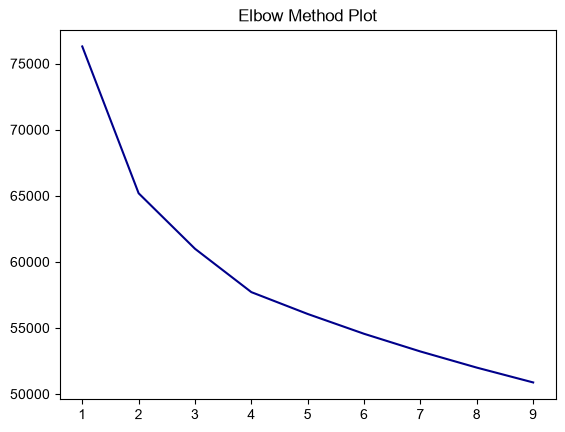

In [26]:
y = np.array([i for i in range(1,10,1)])
plt.plot(y,cost, color = 'darkblue')
sns.set(rc={'axes.facecolor':'#E6DDC4', 'figure.facecolor':'white'})
plt.title('Elbow Method Plot')
plt.show()

Based on the curve of the line on the Elbow Method graph, the optimal number of clusters is 4.

### 5.3 Validation using Calinski-Harabasz Index

In [27]:
from sklearn.metrics import calinski_harabasz_score

ch_result = []
for num_clusters in list(range(2,6)):
    kmode = KModes(n_clusters=num_clusters, init = "Cao", n_init = 1, verbose=1)
    labels = kmode.fit_predict(df3)
    ch_index = calinski_harabasz_score(df3, labels)
    ch_result.append(ch_index)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 65191.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 60992.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 57711.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 56058.0


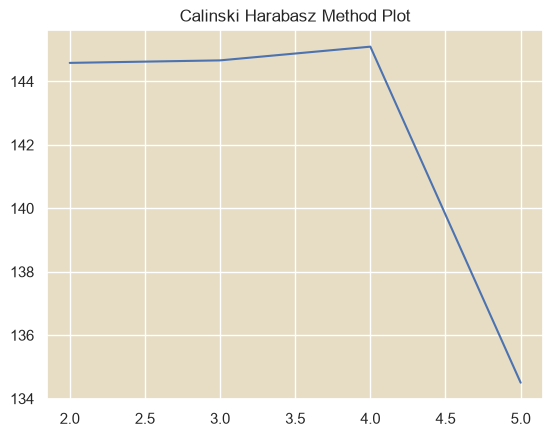

In [28]:
y = np.array([i for i in range(2,6,1)])
plt.plot(y, ch_result)
sns.set(rc={'axes.facecolor':'#E6DDC4', 'figure.facecolor':'white'})
plt.title('Calinski Harabasz Method Plot')
plt.show()

Based on the Calinski-Harabasz plot, the optimal number of clusters is also 4. Therefore, we will set the number of clusters to 4 when performing the clustering.

### 5.4 Final Clustering Model

In [29]:
km_cao = KModes(n_clusters=4, init = "Cao", n_init = 1, verbose=1)
fitClusters_cao = km_cao.fit_predict(df2)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 57711.0


In [30]:
fitClusters_cao

array([3, 0, 0, ..., 0, 0, 3], dtype=uint16)

In [31]:
df2 = df2.reset_index()

In [32]:
clustersDf = pd.DataFrame(fitClusters_cao)
clustersDf.columns = ['cluster_predicted']
combinedDf = pd.concat([df2, clustersDf], axis = 1).reset_index()
combinedDf = combinedDf.drop(['index', 'level_0'], axis = 1)

clustersDf

,cluster_predicted
0,3
1,0
2,0
3,3
4,3
...,...
11269,1
11270,0
11271,0
11272,0


In [33]:
combinedDf.head()

,Gender,Tinggal_Dengan,Status_Kerja,Biaya,Tgl_Daftar_Kuliah,Alamat,UKM,Organisasi_Kampus,Lama_Kuliah,Fakultas,cluster_predicted
0,Pria,Kos,Belum,Beasiswa,2008,Tangerang,UKM_3,Ya,3.5,DKV,3
1,Wanita,Unknown,Belum,Unknown,2009,Bekasi,UKM_2,Tidak,4.0,FIKOM,0
2,Wanita,Unknown,Bekerja,Beasiswa,2008,Serang,UKM_4,Tidak,4.5,FIKOM,0
3,Wanita,Orang Tua,Belum,Beasiswa,2009,Serang,UKM_1,Tidak,5.5,DKV,3
4,Wanita,Orang Tua,Bekerja,Unknown,2009,Bekasi,Tidak,Ya,6.5,DKV,3


## 6. Cluster Profiling
Inspect each cluster individually to understand its characteristics.

In [34]:
cluster_0 = combinedDf[combinedDf['cluster_predicted'] == 0]
cluster_1 = combinedDf[combinedDf['cluster_predicted'] == 1]
cluster_2 = combinedDf[combinedDf['cluster_predicted'] == 2]
cluster_3 = combinedDf[combinedDf['cluster_predicted'] == 3]

### Cluster 0

In [35]:
cluster_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3931 entries, 1 to 11272
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Gender             3931 non-null   object
 1   Tinggal_Dengan     3931 non-null   object
 2   Status_Kerja       3931 non-null   object
 3   Biaya              3931 non-null   object
 4   Tgl_Daftar_Kuliah  3931 non-null   object
 5   Alamat             3931 non-null   object
 6   UKM                3931 non-null   object
 7   Organisasi_Kampus  3931 non-null   object
 8   Lama_Kuliah        3931 non-null   object
 9   Fakultas           3931 non-null   object
 10  cluster_predicted  3931 non-null   uint16
dtypes: object(10), uint16(1)
memory usage: 345.5+ KB


### Cluster 1

In [36]:
cluster_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3141 entries, 7 to 11269
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Gender             3141 non-null   object
 1   Tinggal_Dengan     3141 non-null   object
 2   Status_Kerja       3141 non-null   object
 3   Biaya              3141 non-null   object
 4   Tgl_Daftar_Kuliah  3141 non-null   object
 5   Alamat             3141 non-null   object
 6   UKM                3141 non-null   object
 7   Organisasi_Kampus  3141 non-null   object
 8   Lama_Kuliah        3141 non-null   object
 9   Fakultas           3141 non-null   object
 10  cluster_predicted  3141 non-null   uint16
dtypes: object(10), uint16(1)
memory usage: 276.1+ KB


### Cluster 2

In [37]:
cluster_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2251 entries, 5 to 11252
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Gender             2251 non-null   object
 1   Tinggal_Dengan     2251 non-null   object
 2   Status_Kerja       2251 non-null   object
 3   Biaya              2251 non-null   object
 4   Tgl_Daftar_Kuliah  2251 non-null   object
 5   Alamat             2251 non-null   object
 6   UKM                2251 non-null   object
 7   Organisasi_Kampus  2251 non-null   object
 8   Lama_Kuliah        2251 non-null   object
 9   Fakultas           2251 non-null   object
 10  cluster_predicted  2251 non-null   uint16
dtypes: object(10), uint16(1)
memory usage: 197.8+ KB


### Cluster 3

In [38]:
cluster_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1951 entries, 0 to 11273
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Gender             1951 non-null   object
 1   Tinggal_Dengan     1951 non-null   object
 2   Status_Kerja       1951 non-null   object
 3   Biaya              1951 non-null   object
 4   Tgl_Daftar_Kuliah  1951 non-null   object
 5   Alamat             1951 non-null   object
 6   UKM                1951 non-null   object
 7   Organisasi_Kampus  1951 non-null   object
 8   Lama_Kuliah        1951 non-null   object
 9   Fakultas           1951 non-null   object
 10  cluster_predicted  1951 non-null   uint16
dtypes: object(10), uint16(1)
memory usage: 171.5+ KB


## 7. Visualizing Cluster Characteristics
The following plots compare the distribution of student characteristics across the four predicted clusters. Because the clusters have different total numbers of students, the charts should be interpreted by examining both the dominant category within each cluster and the relative patterns across clusters.

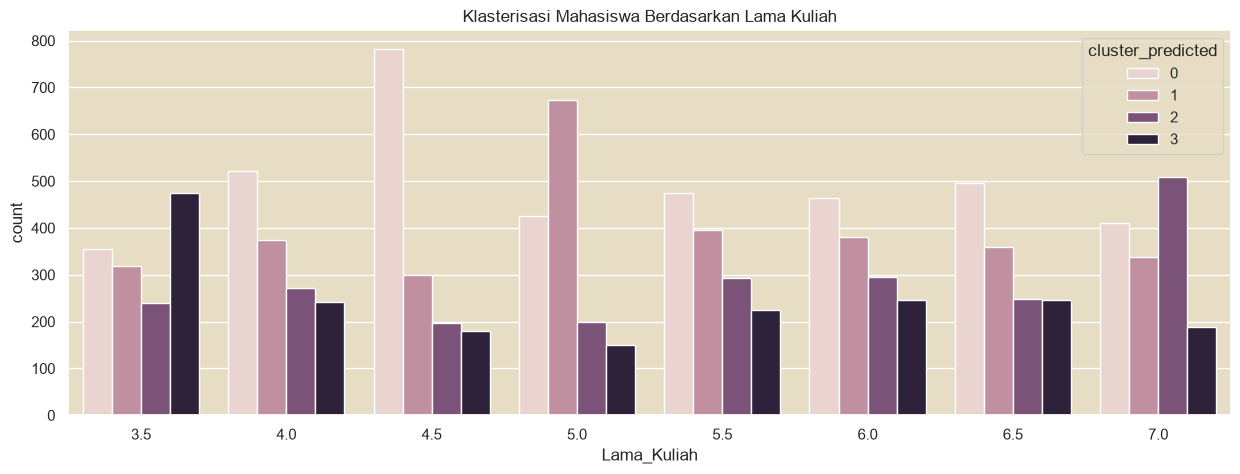

In [ ]:
plt.subplots(figsize = (15,5))
sns.countplot(x=combinedDf['Lama_Kuliah'],hue=combinedDf['cluster_predicted']).set(title='Klasterisasi Mahasiswa Berdasarkan Lama Kuliah')
plt.show()

This chart compares the students' study duration across the four clusters. It helps identify whether certain clusters contain more recently enrolled students, active students, or students who have studied for a longer period.

**Insight:**  

Cluster 0 contains many students with study durations of approximately 4.5 to 7 years, with the highest concentration around 4.5 years. Cluster 1 is strongly represented among students with a study duration of around 5 years, while Cluster 2 has a relatively high number of students at 7 years. Cluster 3 is more concentrated among students with shorter study durations, especially around 3.5 years. This indicates that study duration contributes meaningfully to the separation of the student groups.

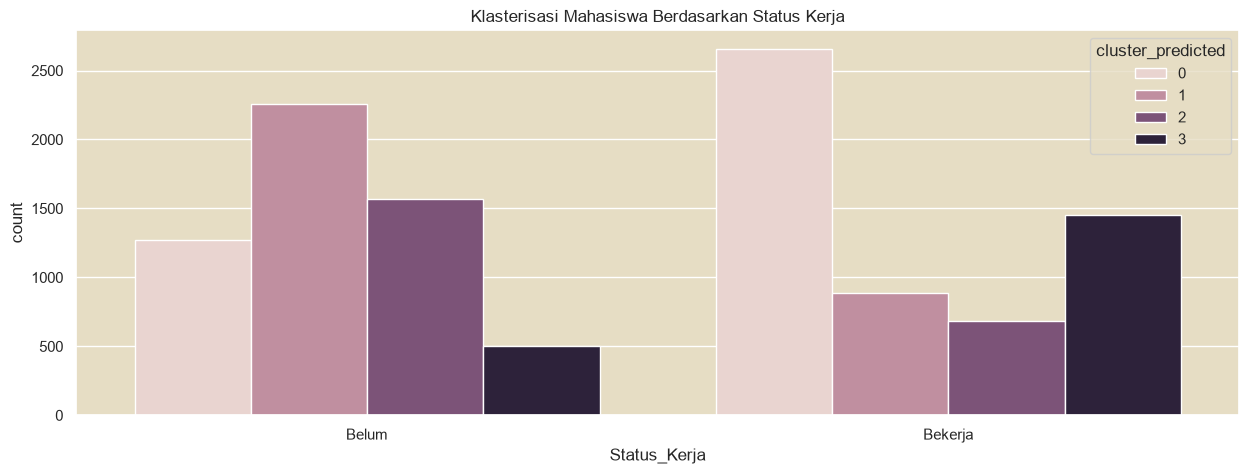

In [40]:
plt.subplots(figsize = (15,5))
sns.countplot(x=combinedDf['Status_Kerja'],hue=combinedDf['cluster_predicted']).set(title='Klasterisasi Mahasiswa Berdasarkan Status Kerja')
plt.show()

This chart shows the distribution of working (Belum) and non-working (Bekerja) students in each cluster. It helps reveal whether employment status is one of the characteristics that distinguishes the student groups.

**Insight:**  

Cluster 0 consists predominantly of working students, whereas Cluster 1 is dominated by students who are not currently employed. Cluster 2 also contains more non-working than working students, while Cluster 3 has a relatively large proportion of working students. Employment status therefore appears to be an important characteristic distinguishing the clusters.

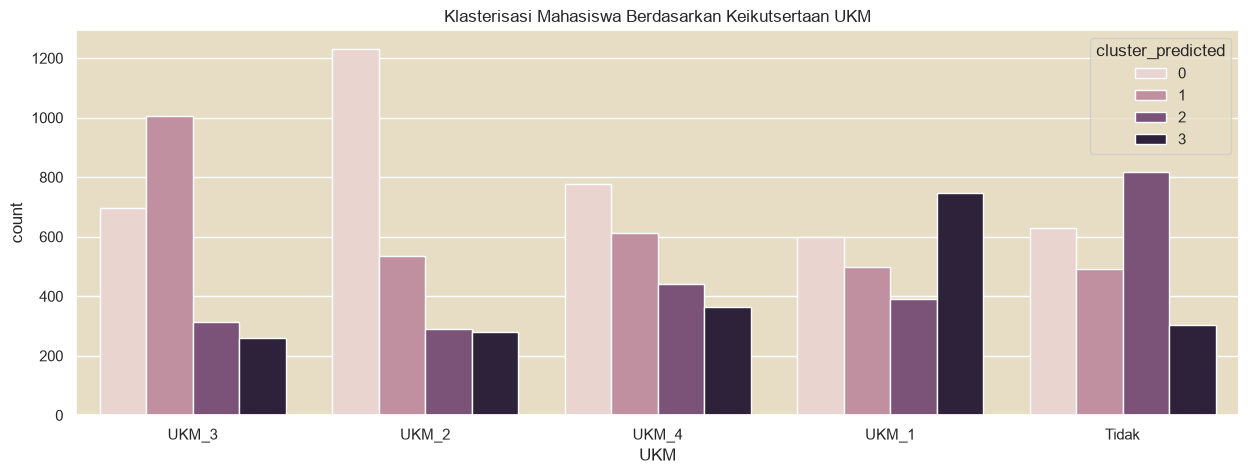

In [41]:
plt.subplots(figsize = (15,5))
sns.countplot(x=combinedDf['UKM'],hue=combinedDf['cluster_predicted']).set(title='Klasterisasi Mahasiswa Berdasarkan Keikutsertaan UKM')
plt.show()

This chart compares student participation in university activity units, or UKM, across the clusters. It provides an overview of differences in extracurricular involvement among the student groups.

**Insight:**  

The clusters show different patterns of extracurricular participation. Cluster 0 is strongly represented in several UKM categories, especially UKM 2, while Cluster 1 has the highest representation in UKM 3. Cluster 2 contains many students who do not participate in a UKM, whereas Cluster 3 has a relatively high number of students in UKM 1. These differences suggest that extracurricular interests help characterize the student segments.

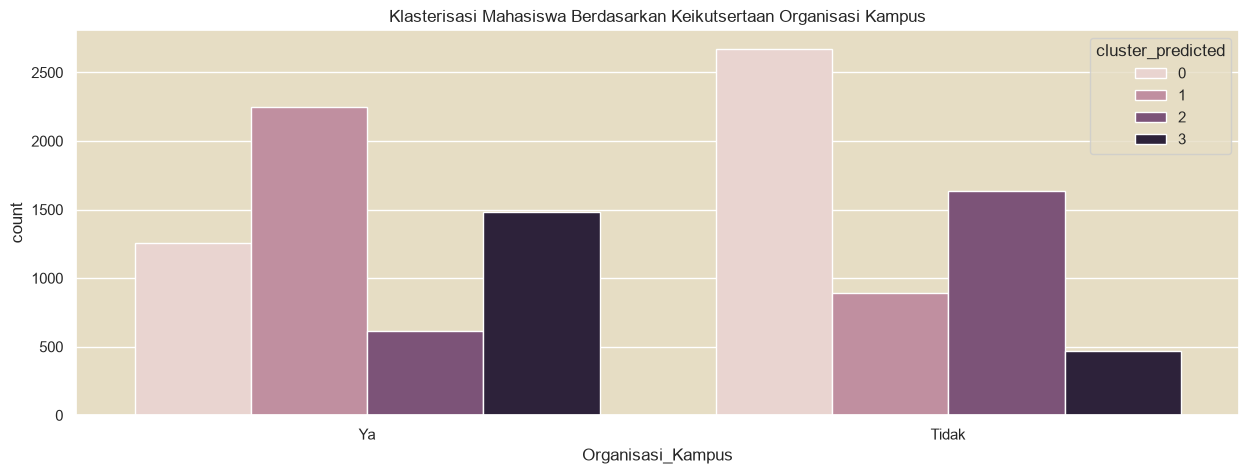

In [42]:
plt.subplots(figsize = (15,5))
sns.countplot(x=combinedDf['Organisasi_Kampus'],hue=combinedDf['cluster_predicted']).set(title='Klasterisasi Mahasiswa Berdasarkan Keikutsertaan Organisasi Kampus')
plt.show()

This chart shows the distribution of students who participate in campus organizations within each cluster (Participate = Ya, Not Participate = Tidak). It helps identify clusters with relatively high or low organizational involvement.

**Insight:**  

Cluster 0 and Cluster 2 contain more students who do not participate in campus organizations. In contrast, Cluster 1 and Cluster 3 contain substantially more students who participate in such organizations. This suggests that organizational involvement is one of the clearest behavioral differences between the clusters.

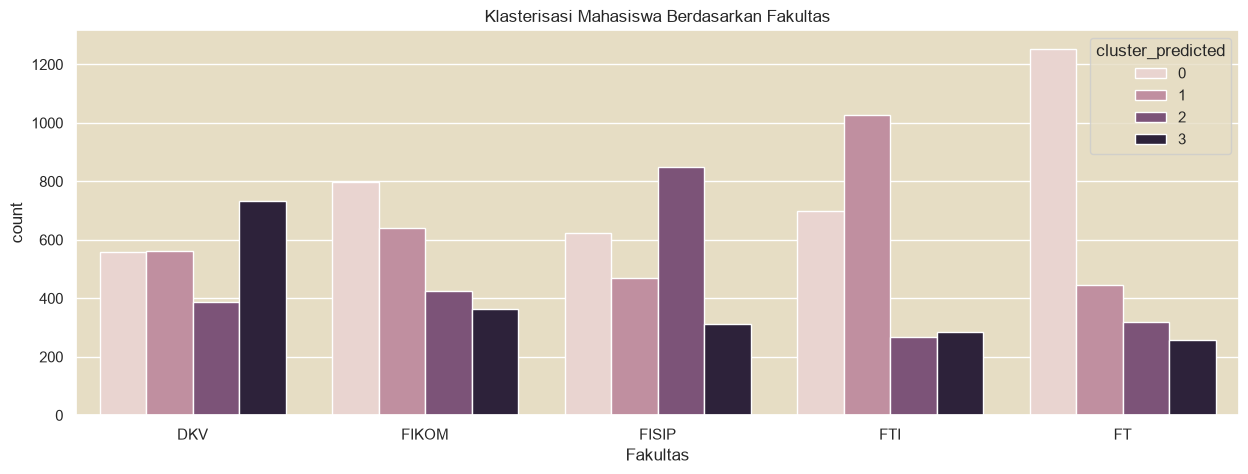

In [43]:
plt.subplots(figsize = (15,5))
sns.countplot(x=combinedDf['Fakultas'],hue=combinedDf['cluster_predicted']).set(title='Klasterisasi Mahasiswa Berdasarkan Fakultas')
plt.show()

This chart compares the faculty (Fakultas) composition of each cluster. It helps determine whether students from particular academic fields are more strongly represented in certain clusters.
- DKV = Faculty of Visual and Communication Design
- FIKOM = Faculty of Communication Science
- FISIP = Faculty of Political and Social Science
- FTI = Faculty of Industrial Technology
- FT = Faculty of Engineering

**Insight:**  

Each cluster has a different dominant faculty. Cluster 0 has a particularly large representation from FT, Cluster 1 is strongly represented by FTI students, Cluster 2 contains many FISIP students, and Cluster 3 has its highest representation in DKV. Faculty background therefore plays a notable role in defining the cluster profiles.

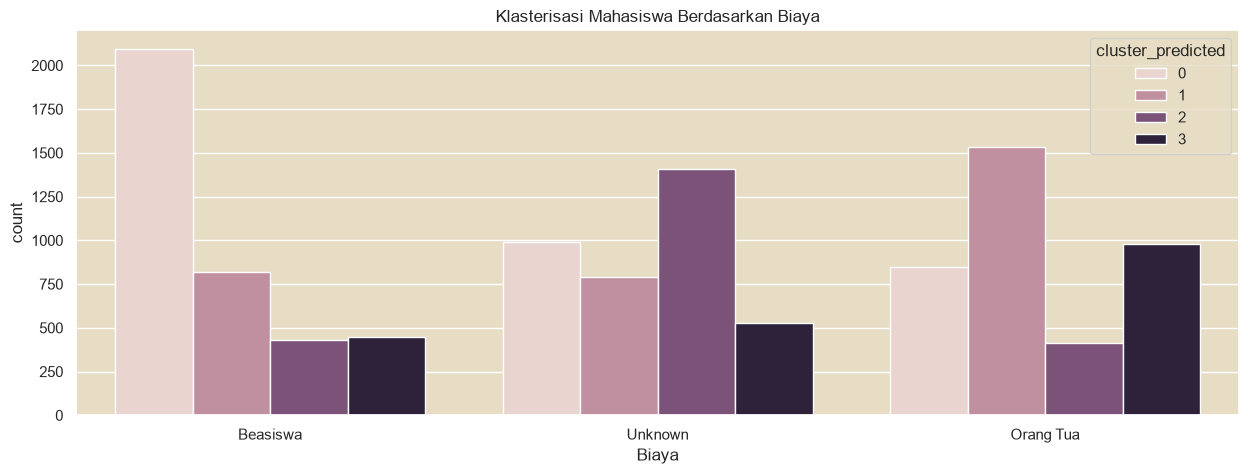

In [44]:
plt.subplots(figsize = (15,5))
sns.countplot(x=combinedDf['Biaya'],hue=combinedDf['cluster_predicted']).set(title='Klasterisasi Mahasiswa Berdasarkan Biaya')
plt.show()

This chart shows how students finance their education across the four clusters. It helps identify differences in financial backgrounds, such as students supported by parents (Orang Tua), scholarships (Beasiswa), as well as both unknown label including personal income and other funding sources.

**Insight:**  

Cluster 0 contains a large number of scholarship-funded students, while Cluster 1 is dominated by students whose education is funded by their parents. Cluster 2 has many records with an unknown funding source, and Cluster 3 is also strongly represented among parent-funded students. These patterns indicate differences in the socioeconomic and financial backgrounds of the clusters.

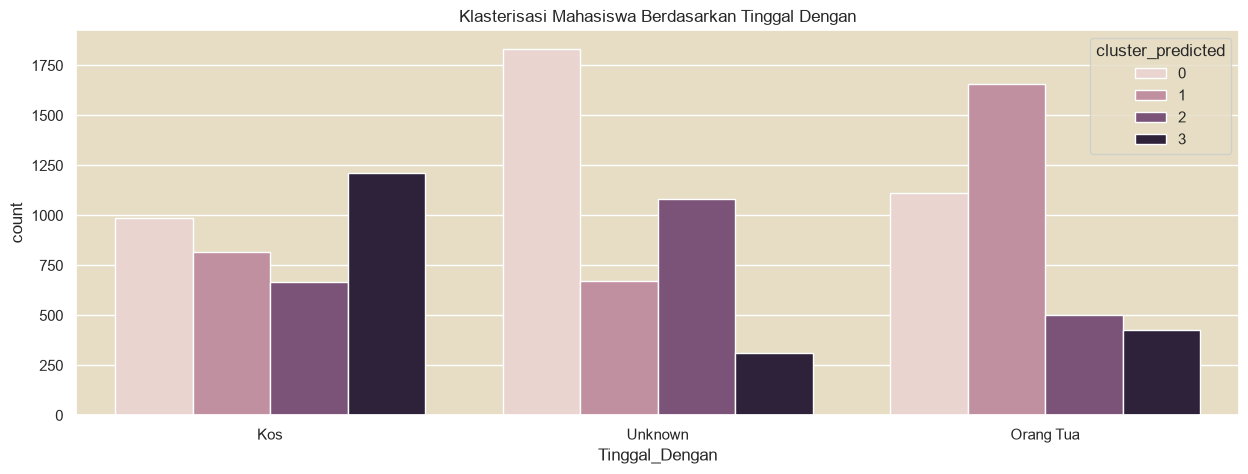

In [45]:
plt.subplots(figsize = (15,5))
sns.countplot(x=combinedDf['Tinggal_Dengan'],hue=combinedDf['cluster_predicted']).set(title='Klasterisasi Mahasiswa Berdasarkan Tinggal Dengan')
plt.show()

This chart compares students living arrangements across the clusters. It shows whether students live with parents (Orang Tua), independently in dorm or apartment (Kos), or under other arrangements (Unknown).

**Insight:**  

Cluster 0 contains many students whose living arrangement is recorded as unknown, while Cluster 1 is dominated by students living with their parents. Cluster 2 also has a high number of unknown living arrangements, whereas Cluster 3 contains a comparatively large number of students living in boarding houses or rented accommodation. Living arrangement therefore helps distinguish students who may have different levels of family support or independence.

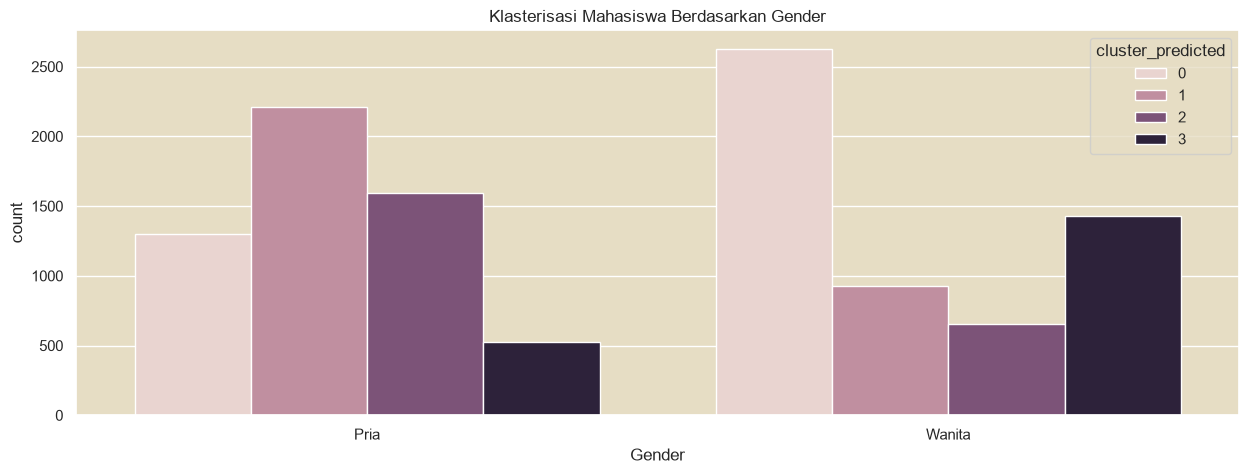

In [46]:
plt.subplots(figsize = (15,5))
sns.countplot(x=combinedDf['Gender'],hue=combinedDf['cluster_predicted']).set(title='Klasterisasi Mahasiswa Berdasarkan Gender')
plt.show()

This chart displays the gender distribution within each cluster (Man = Pria, Woman = Wanita). It helps determine whether any cluster is predominantly represented by a particular gender.

**Insight:**  

Cluster 0 and Cluster 3 contain more female than male students. In contrast, Cluster 1 and Cluster 2 contain considerably more male students. Gender is therefore associated with the cluster composition, although it should be interpreted together with academic and socioeconomic characteristics rather than as a standalone explanation.

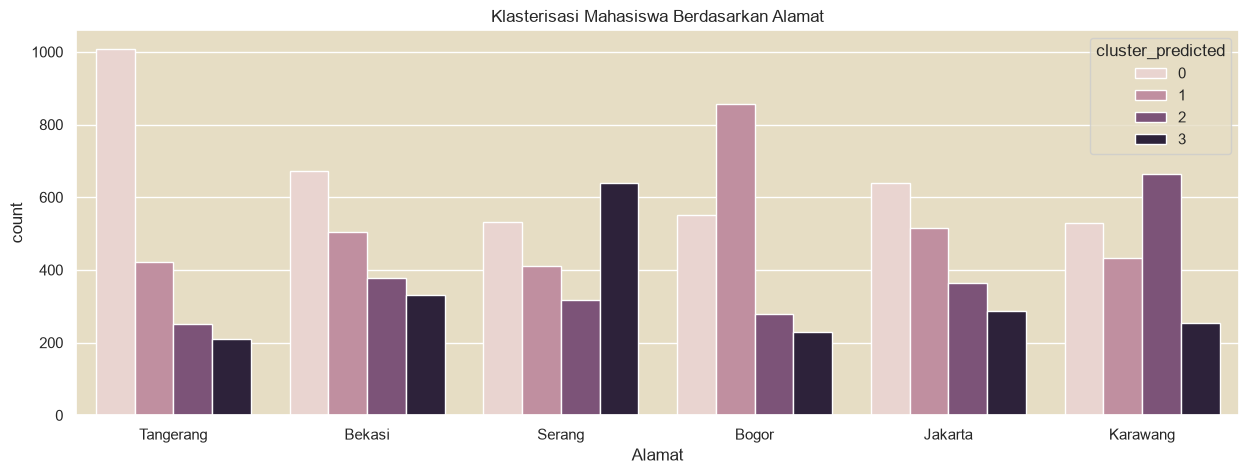

In [47]:
plt.subplots(figsize = (15,5))
sns.countplot(x=combinedDf['Alamat'],hue=combinedDf['cluster_predicted']).set(title='Klasterisasi Mahasiswa Berdasarkan Alamat')
plt.show()

This chart compares the students' residential locations across the clusters. It helps reveal whether geographic background or place of residence contributes to the differences between student groups.

**Insight:**  

Cluster 0 has its highest representation in Tangerang, while Cluster 1 contains many students from Bogor. Cluster 2 is particularly prominent among students from Karawang, and Cluster 3 has a relatively high number of students from Serang. The location patterns suggest that geographic background may contribute to differences in access, commuting conditions, or student lifestyles.

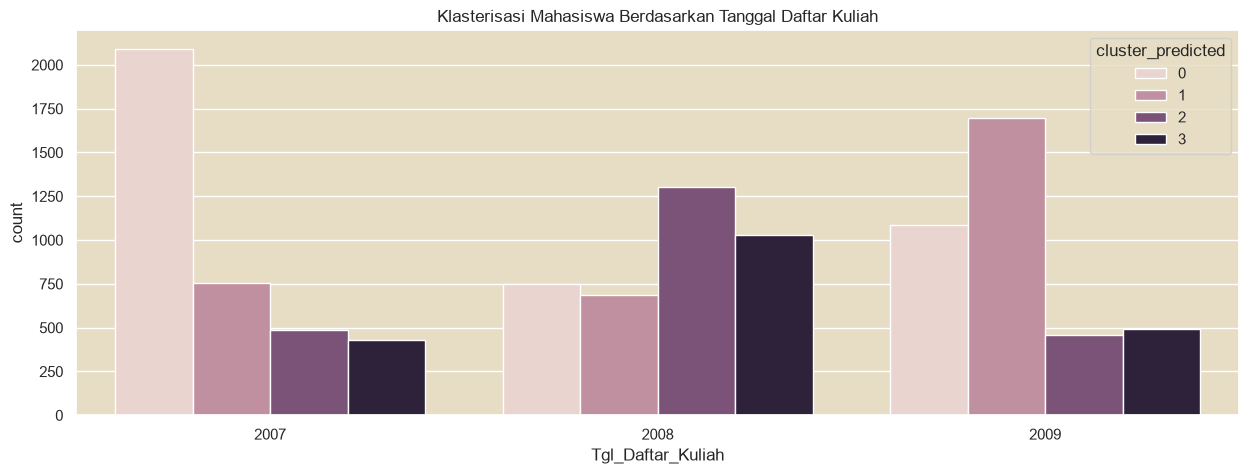

In [48]:
plt.subplots(figsize = (15,5))
sns.countplot(x=combinedDf['Tgl_Daftar_Kuliah'],hue=combinedDf['cluster_predicted']).set(title='Klasterisasi Mahasiswa Berdasarkan Tanggal Daftar Kuliah')
plt.show()

This chart shows the distribution of university enrollment periods across the clusters. It helps identify whether each cluster contains students from different enrollment cohorts or academic years.

**Insight:**  

Cluster 0 contains a large number of students enrolled in 2007, while Cluster 1 is strongly represented among students enrolled in 2009. Clusters 2 and 3 contain relatively more students from the 2008 cohort. This shows that the clusters partly reflect different enrollment cohorts and stages of academic progression.

### Overall Insight from the Visualizations

The visualizations show that no single variable completely defines the clusters. Instead, the segmentation is produced by combinations of study duration, employment, extracurricular participation, faculty, financial support, living arrangement, gender, location, and enrollment year.

Among these variables, **employment status, campus organization participation, faculty, education funding source, living arrangement, and enrollment year** show some of the clearest differences between clusters.

## 8. Conclusion

This project demonstrates how **K-Modes clustering** can be used to segment students based on categorical demographic, academic, socioeconomic, and extracurricular characteristics.

The cluster evaluation indicated that **four clusters** provided a suitable representation of the student population. Each cluster showed a different combination of academic performance, student activities, financial background, living arrangements, and other characteristics.

The results shows that students should not be treated as a single homogeneous group. Instead, each student segment may require a different academic support strategy. Depending on the characteristics of the cluster, possible interventions may include:

* Academic mentoring and study support
* Scholarship and financial assistance
* Leadership and organizational development
* Career preparation and employment guidance
* More personalized academic planning

Overall, the analysis shows that unsupervised machine learning can help educational institutions identify meaningful student profiles and support more targeted, data-driven academic programs.

### Further Interpretation

A more detailed explanation of the cluster characteristics and the recommended academic programs is available in **`Rencana_Akademik_Paper.pdf`**. Refer to:

* **Hasil dan Pembahasan** for the detailed interpretation and comparison of the four clusters.
* **Rekomendasi Rencana Akademik** for the proposed academic programs and interventions for each student group.
* **Kesimpulan dan Saran** for the overall conclusions, limitations, and recommendations of the project.